<a href="https://colab.research.google.com/github/OutisAyo/council-classifier-/blob/main/notebooks/06_xgboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning for Automated Classification and Prioritisation of Local Council Service Requests in the UK
## Notebook 06 XGBoost Classifier (Department Prediction)

**Author:** Fashina Fuad Ayomide  
**MSc Data Science, University of South Wales**

This notebook builds an XGBoost classifier to predict the assigned department from the request text, the final model in our comparison of four algorithms.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Importing the libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Importing the processed data

In [3]:
processed_dir = '/content/drive/MyDrive/council-classifier/processed'

X_train = np.load(f'{processed_dir}/X_train.npy', allow_pickle=True)
X_test = np.load(f'{processed_dir}/X_test.npy', allow_pickle=True)
y_dept_train = np.load(f'{processed_dir}/y_dept_train.npy', allow_pickle=True)
y_dept_test = np.load(f'{processed_dir}/y_dept_test.npy', allow_pickle=True)

print("Training set size:", len(X_train))
print("Test set size:", len(X_test))

Training set size: 203501
Test set size: 50876


## Converting text to numerical features using Bag of Words

In [4]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(max_features=1500)
X_train_vec = cv.fit_transform(X_train).toarray()
X_test_vec = cv.transform(X_test).toarray()

print("Training matrix shape:", X_train_vec.shape)
print("Test matrix shape:", X_test_vec.shape)

Training matrix shape: (203501, 579)
Test matrix shape: (50876, 579)


## Encoding the target labels

XGBoost requires numeric class labels rather than text strings, unlike the previous three models.

In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_dept_train_encoded = le.fit_transform(y_dept_train)
y_dept_test_encoded = le.transform(y_dept_test)

print("Department classes:", le.classes_)
print("\nExample encoding:")
for i in range(5):
    print(f"  {y_dept_train[i]} -> {y_dept_train_encoded[i]}")

Department classes: ['Food and Safety Division' 'Housing Division' 'Licensing Division'
 'Pollution Division' 'Trading Standards Division' 'Waste Management']

Example encoding:
  Waste Management -> 5
  Waste Management -> 5
  Pollution Division -> 3
  Waste Management -> 5
  Pollution Division -> 3


## Training the XGBoost model on the Training set

XGBoost builds decision trees sequentially, where each new tree corrects the errors of the previous ones, a technique called gradient boosting.

In [6]:
from xgboost import XGBClassifier

classifier = XGBClassifier(n_estimators=100, random_state=0, eval_metric='mlogloss')
classifier.fit(X_train_vec, y_dept_train_encoded)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

## Predicting the Test set results

In [7]:
y_pred_encoded = classifier.predict(X_test_vec)
y_pred = le.inverse_transform(y_pred_encoded)

print("Sample predictions vs actual:")
comparison = pd.DataFrame({'Predicted': y_pred[:15], 'Actual': y_dept_test[:15]})
print(comparison)

Sample predictions vs actual:
                   Predicted                    Actual
0           Waste Management          Waste Management
1         Pollution Division        Pollution Division
2           Waste Management          Waste Management
3         Pollution Division        Pollution Division
4           Waste Management          Waste Management
5   Food and Safety Division  Food and Safety Division
6           Waste Management          Waste Management
7           Waste Management          Waste Management
8         Licensing Division        Licensing Division
9           Waste Management          Waste Management
10          Waste Management          Waste Management
11          Waste Management          Waste Management
12        Pollution Division        Pollution Division
13          Waste Management          Waste Management
14          Waste Management          Waste Management


## Making the Confusion Matrix

In [8]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cm = confusion_matrix(y_dept_test, y_pred)
print("Confusion Matrix:")
print(cm)

print("\nAccuracy:", accuracy_score(y_dept_test, y_pred))

Confusion Matrix:
[[ 1179     0     3     1     0     0]
 [    1  2094     1     3     0     4]
 [    0     0  1598     2     5     0]
 [    0     5     0  6393     0     6]
 [    2     1     1     4   175     1]
 [    0     1     0    30     0 39366]]

Accuracy: 0.9986044500353801


## Classification Report

In [9]:
print(classification_report(y_dept_test, y_pred))

                            precision    recall  f1-score   support

  Food and Safety Division       1.00      1.00      1.00      1183
          Housing Division       1.00      1.00      1.00      2103
        Licensing Division       1.00      1.00      1.00      1605
        Pollution Division       0.99      1.00      1.00      6404
Trading Standards Division       0.97      0.95      0.96       184
          Waste Management       1.00      1.00      1.00     39397

                  accuracy                           1.00     50876
                 macro avg       0.99      0.99      0.99     50876
              weighted avg       1.00      1.00      1.00     50876



## Visualising the Confusion Matrix

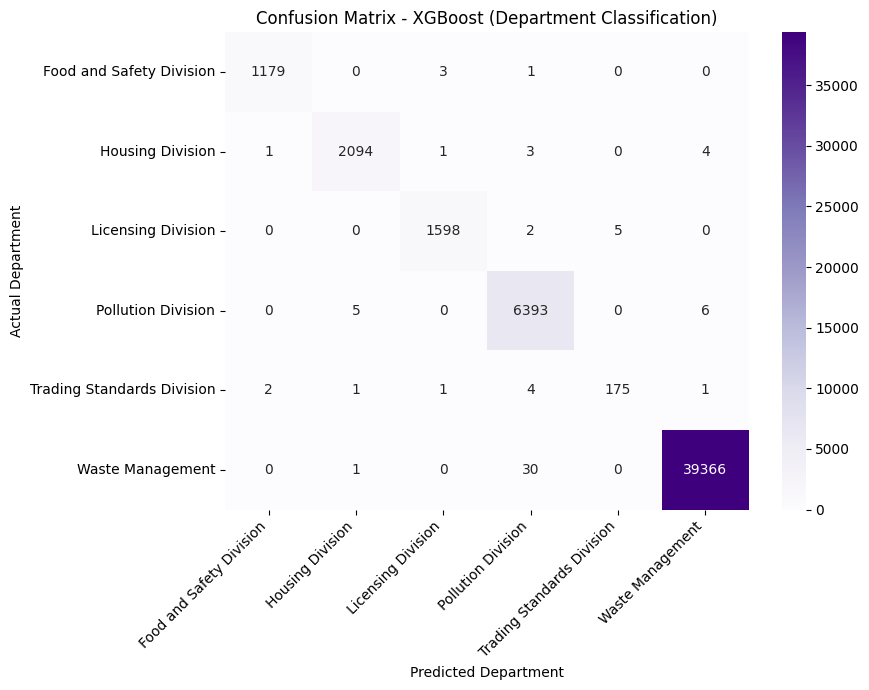

In [10]:
plt.figure(figsize=(9, 7))
unique_labels = sorted(set(y_dept_test))

sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=unique_labels, yticklabels=unique_labels)
plt.title('Confusion Matrix - XGBoost (Department Classification)')
plt.xlabel('Predicted Department')
plt.ylabel('Actual Department')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Appending results to the comparison file

In [12]:
from sklearn.metrics import f1_score

results_path = '/content/drive/MyDrive/council-classifier/processed/model_results.csv'
results_df = pd.read_csv(results_path)

new_result = {
    'model': 'XGBoost',
    'accuracy': accuracy_score(y_dept_test, y_pred),
    'f1_macro': f1_score(y_dept_test, y_pred, average='macro'),
    'f1_weighted': f1_score(y_dept_test, y_pred, average='weighted')
}

results_df = pd.concat([results_df, pd.DataFrame([new_result])], ignore_index=True)
results_df.to_csv(results_path, index=False)

print(results_df)

                 model  accuracy  f1_macro  f1_weighted
0          Naive Bayes  0.997956  0.979528     0.997955
1  Logistic Regression  0.998585  0.991498     0.998584
2        Random Forest  0.998663  0.992122     0.998662
3              XGBoost  0.998604  0.991088     0.998604
